In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, validation_curve
from xgboost.sklearn import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=8,
    n_redundant=3,
    n_repeated=2,
    random_state=42,
)

In [3]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [4]:
default_params = {
    "objective": "binary:logistic",
    "max_depth": 1,
    "learning_rate": 0.3,
    "silent": 1.0,
    "seed": 42,
}

n_estimators_range = np.linspace(1, 200, 10).astype("int")

train_scores, test_scores = validation_curve(
    XGBClassifier(**default_params),
    X,
    y,
    param_name="n_estimators",
    param_range=n_estimators_range,
    cv=cv.split(X, y),
    scoring="accuracy",
    n_jobs=-1,
)

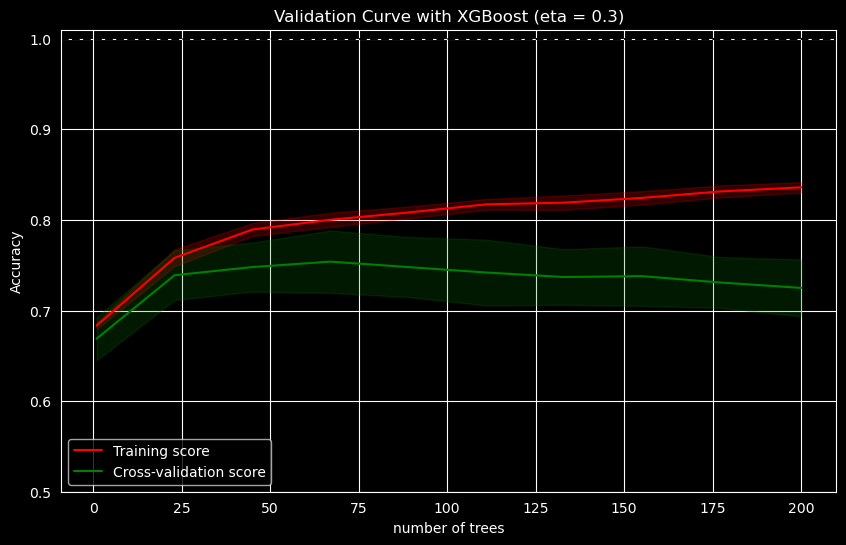

Best cross-validation result (0.75) obtained for 67 trees


In [5]:
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

fig = plt.figure(figsize=(10, 6), dpi=100)

plt.title("Validation Curve with XGBoost (eta = 0.3)")
plt.xlabel("number of trees")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.01)

plt.plot(n_estimators_range, train_scores_mean, label="Training score", color="r")
plt.plot(n_estimators_range, test_scores_mean, label="Cross-validation score", color="g")

plt.fill_between(
    n_estimators_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2,
    color="r",
)

plt.fill_between(
    n_estimators_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2,
    color="g",
)

plt.axhline(y=1, color="k", ls="dashed")
plt.legend(loc="best")
plt.show()

i = np.argmax(test_scores_mean)
print(
    "Best cross-validation result ({0:.2f}) obtained for {1} trees".format(
        test_scores_mean[i], n_estimators_range[i]
    )
)

In [6]:
new_params = {
    "objective": "binary:logistic",
    "max_depth": 2,
    "learning_rate": 0.3,
    "silent": 1.0,
    "colsample_bytree": 0.6,
    "subsample": 0.7,
    "seed": 42,
}

n_estimators_range = np.linspace(1, 200, 10).astype("int")

train_scores, test_scores = validation_curve(
    XGBClassifier(**new_params),
    X,
    y,
    param_name="n_estimators",
    param_range=n_estimators_range,
    cv=cv.split(X, y),
    scoring="accuracy",
)

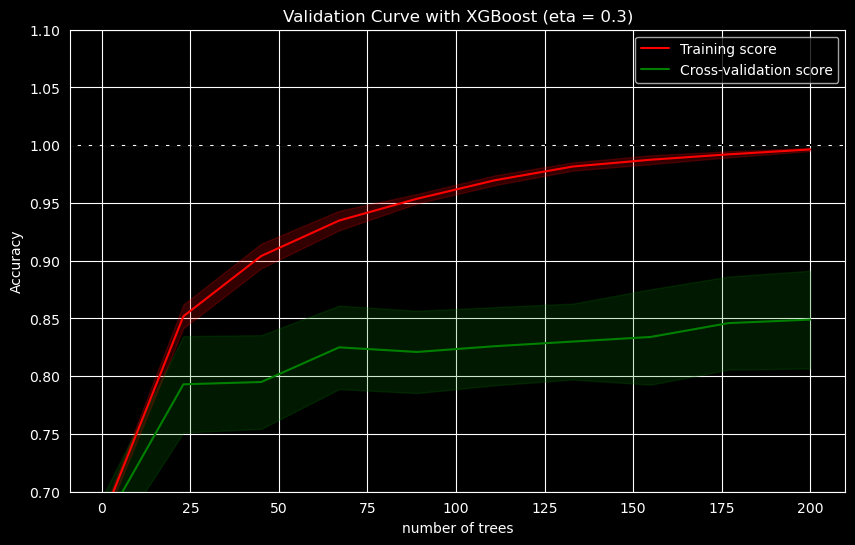

Best cross-validation result (0.85) obtained for 200 trees


In [7]:
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

fig = plt.figure(figsize=(10, 6), dpi=100)

plt.title("Validation Curve with XGBoost (eta = 0.3)")
plt.xlabel("number of trees")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.1)

plt.plot(n_estimators_range, train_scores_mean, label="Training score", color="r")
plt.plot(n_estimators_range, test_scores_mean, label="Cross-validation score", color="g")

plt.fill_between(
    n_estimators_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2,
    color="r",
)

plt.fill_between(
    n_estimators_range,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2,
    color="g",
)

plt.axhline(y=1, color="k", ls="dashed")
plt.legend(loc="best")
plt.show()

i = np.argmax(test_scores_mean)
print(
    "Best cross-validation result ({0:.2f}) obtained for {1} trees".format(
        test_scores_mean[i], n_estimators_range[i]
    )
)